In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from src.utils import get_dataset, get_diffusion_schedule_nickname, get_diffusion_weights, get_n_qubits_from_data, set_device, get_path
from src.QDDPM_torch_angel import QDDPMDiffuser
from tqdm import tqdm
import pytorch_optimizer
from functools import partial
from livelossplot import PlotLosses
from opt_einsum import contract
import qutip as qt
from qutip import Bloch
from src.QDDPM_torch_angel import WassDistance
from sklearn.model_selection import train_test_split
def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

I0000 00:00:1776260712.368718 1258843 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776260713.427162 1258843 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
/home/angel/miniconda3/envs/dffs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as n

# 1 qubit. Clustered states.

## Import and visualize them

In [2]:
config = {
    'device': 'cpu',
    'seed': 0,
    'dataset': {
        'dir': './results_MLP',
        'name': 'CLUSTER0_1',
        # 'transforms': {
        #     'resize': 16
        # },
        'maxsize': 200
    },
    'model': {
        'n_timesteps': 20,
        'diffusion_schedule': {
            'name': 'linear',
            'slope': 6,
            # 'vrescale': 50,
            # 'hrescale': 26
        }
    }
}
n_qubits = int(config["dataset"]["name"].split('_')[1])
n_features = 2**n_qubits
diffusion_schedule_nickname = get_diffusion_schedule_nickname(config)
n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
device = set_device(config.get('device', 'cpu'))
get_path_partial = partial(get_path, config, modeltype='MLP', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)

Using device: cpu


Initial quantum states not found. Generating them...
Loaded dataset CLUSTER0_1 with 200 samples.
Dataset saved in results_MLP/CLUSTER0_1/initialqstates/initialqstates_CLUSTER0_1_N200_M2_n1.npy


100%|██████████| 21/21 [00:00<00:00, 80.35it/s]


Text(0.5, 1.0, 'Quantum state distribution during the forward process.\nlinear-slope6')

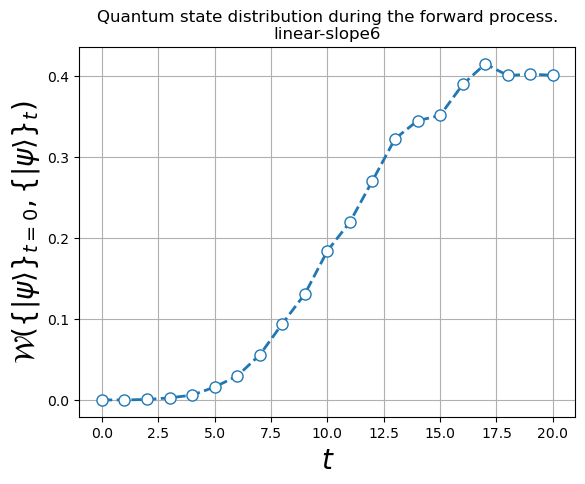

In [3]:
diffuser = QDDPMDiffuser(config, n_data, n_timesteps, n_features, device=device)
states_diffused =diffuser.diffuse()
wass = diffuser.compute_wassdist_forward()

fig, ax1 = plt.subplots()
ax1.plot(wass, 'o--', mfc='white', markersize=8, lw=2)
# plt.plot(wass)
ax1.set_ylabel(r'$\mathcal{W}\left(\{|\psi\rangle\}_{t=0}, \{|\psi\rangle\}_{t} \right)$', fontsize=20)
ax1.set_xlabel(r'$t$', fontsize=20)
# plt.xticks(range(n_timesteps+1))
ax1.grid(True)
ax1.set_title(f'Quantum state distribution during the forward process.\n{diffusion_schedule_nickname}')

# ax2 = ax1.twinx()
# ax2.plot(diffusion_weights.cpu(), c='orange', label='Diffusion weight')

100%|██████████| 21/21 [00:08<00:00,  2.35it/s]


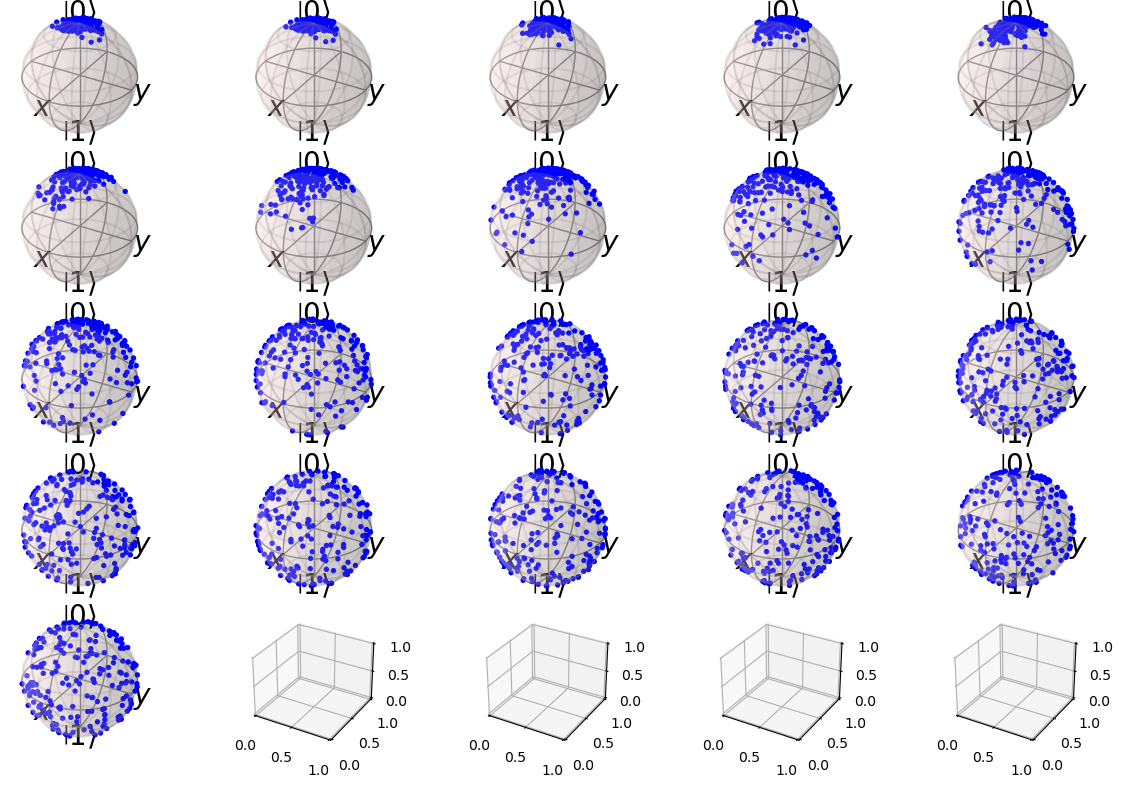

In [4]:
# Bloch visualize on the forward noise process
from opt_einsum import contract
import qutip as qt
from qutip import Bloch

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

cols = 5
fig, axs = plt.subplots(n_timesteps//cols+1, cols, figsize=(12, 8), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    states = states_diffused[i].numpy()
    xs0, ys0, zs0 = bloch_xyz(states)
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()

# Train step-by-step

In [5]:
class MLP(torch.nn.Module):
    def __init__(self, input_feats, n_hidden_layers, output_feats):
        super().__init__()
        input_dim = 2*input_feats
        output_dim = 2*output_feats
        hidden_dim = 4*input_dim
        layers = []
        for _ in range(n_hidden_layers):
            layers.append(torch.nn.Linear(input_dim, hidden_dim))
            layers.append(torch.nn.ReLU())
            input_dim = hidden_dim
        layers.append(torch.nn.Linear(input_dim, output_dim))
        self.mlp = torch.nn.Sequential(*layers)

    def forward(self, x): # x.shape = (batch_size, n_features (complex))
        batch_size = x.shape[0]
        x = torch.view_as_real(x) # (batch_size, n_features, 2)
        x = x.view(batch_size, -1)
        x_output = self.mlp(x)
        x_output = x_output.view(batch_size, -1, 2)
        x_output = torch.view_as_complex(x_output)
        norm = torch.linalg.norm(x_output, dim=1, keepdim=True)
        x_output = x_output / norm
        return x_output
    
def quantum_mean_infidelity(pred, true):
    # pred and true are [n_data, n_features] complex tensors
    inner_product = torch.linalg.vecdot(true, pred, dim=-1) # [n_data]
    fidelity = inner_product.abs().pow(2)
    infidelity = 1 - fidelity
    return infidelity.mean()

def mse(pred, true):
    pred_float = torch.view_as_real(pred)
    true_float = torch.view_as_real(true)
    return torch.nn.functional.mse_loss(pred_float, true_float)

def simple_regularization_term(model, lambd=0.1):
    return lambd * sum(p.pow(2).sum() for p in model.parameters())

def eval(model, x):
    model.eval()
    y = model(x)
    return y

In [6]:
# Declaramos el modelo
device = torch.device('cpu')
input_feats = 2**n_qubits
output_feats = input_feats
n_hidden_layers = 1
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)#.to(torch.float64)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)
print(model)

148
MLP(
  (mlp): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
)


## Trainings

Timestep 20

In [7]:
# Savedir
savedir = Path('results_mlp_pocoapoco/models')

from livelossplot.outputs import MatplotlibPlot
def custom_after_subplot(ax: plt.Axes, group_name: str, x_label: str):
    ax.set_title(group_name)
    ax.set_xlabel(x_label)
    ax.legend(loc='center right')
    ax.set_yscale('log')
outputs = [MatplotlibPlot(after_subplot=custom_after_subplot)]

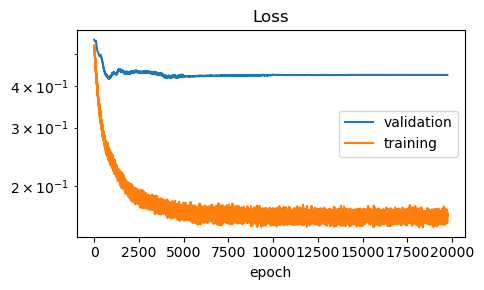

Epoch 20000/20000 Loss: 4.312e-01, Last_save: 18151: 100%|██████████| 20000/20000 [01:07<00:00, 296.38it/s]


In [8]:
# Training loop
loss_fn = quantum_mean_infidelity
lr = 4e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# optimizer = pytorch_optimizer.SOAP(model.parameters(), lr=lr)
step_size = 5000
n_epochs = 4*step_size
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size, gamma=0.1)
pbar = tqdm(range(n_epochs))
batch_size = 100
liveloss = PlotLosses(figsize=(9,3), outputs=outputs)

# Select a timestep
TIMESTEP = 20 # 20 --> 19
X, y = states_diffused[TIMESTEP], states_diffused[TIMESTEP-1]
ts = torch.ones_like(X) * TIMESTEP

train_size = 0.8
X_train, X_val, y_train, y_val, ts_train, ts_val = train_test_split(X, y, ts, train_size=train_size)
train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train, ts_train), batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val, ts_val), batch_size=batch_size, shuffle=False)

logs = {}
epochs = []
val_epochs = []
best_loss = float('inf')
last_save_epoch = 0
for epoch in pbar:
    model.train()
    train_loss_epoch = 0
    for batch in train_dataloader:
        X, y, ts = batch
        # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        x = model(X)
        loss = loss_fn(x, y)# + simple_regularization_term(model, lambd=1e-1)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        train_loss_epoch += loss_value
    lr_scheduler.step()
    avg_train_loss_epoch = train_loss_epoch / len(train_dataloader)

    model.eval()
    with torch.no_grad():
        val_loss_epoch = 0
        for batch in val_dataloader:
            X, y, ts = batch
            # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
            X, y = X.to(device), y.to(device)
            x = model(X)
            loss = loss_fn(x, y)
            loss_value = loss
            val_loss_epoch += loss_value
        avg_val_loss_epoch = val_loss_epoch / len(val_dataloader)
        logs['val_loss'] = avg_val_loss_epoch
        val_epochs.append(epoch)

    logs['loss'] = avg_train_loss_epoch
    epochs.append(epoch)
    liveloss.update(logs)
    pbar.set_description(f'Epoch {epoch+1}/{n_epochs} Loss: {loss_value:.3e}, Last_save: {last_save_epoch}')

    if avg_train_loss_epoch < best_loss:
        best_loss = avg_train_loss_epoch
        last_save_epoch = epoch
        filename = f'bestmodel_pretrained_{TIMESTEP}.pt'
        path = savedir/filename
        savedir.mkdir(parents=True, exist_ok=True)
        torch.save({
                'model_state_dict': model.state_dict(),
                'train_loss_hist': logs['loss'],
                'val_loss_hist': logs['val_loss'],
                'epochs_hist': epochs,
                'val_epochs_hist': val_epochs
                }, path)
    if epoch % 299 == 0:
            liveloss.send()

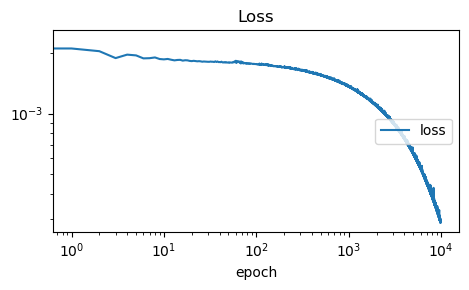

Epoch 10000/10000 Loss: 4.828e-04, Last_save: 9973: 100%|██████████| 10000/10000 [00:39<00:00, 254.56it/s]


In [ ]:
# Change the learning rate
lr = 1e-5

TIMESTEP = 20
filename = f'bestmodel_pretrained_{TIMESTEP}.pt'
checkpoint = torch.load(savedir/filename, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
loss_fn = quantum_mean_infidelity
# loss_fn = mse
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# optimizer = pytorch_optimizer.SOAP(model.parameters(), lr=lr)
# lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=lr*0.001)
n_epochs = 10000
pbar = tqdm(range(n_epochs))
batch_size = 100
liveloss = PlotLosses(figsize=(9,3), outputs=outputs)

# Select a timestep
TIMESTEP = 20 # 20 --> 19
X, y = states_diffused[TIMESTEP], states_diffused[TIMESTEP-1]
ts = torch.ones_like(X) * TIMESTEP
train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y, ts), batch_size=batch_size, shuffle=True)

logs = {}
best_loss = float('inf')
last_save_epoch = 0
model.train()
for epoch in pbar:
    train_loss_epoch = 0
    for batch in train_dataloader:
        X, y, ts = batch
        # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        x = model(X)
        loss = loss_fn(x, y)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        train_loss_epoch += loss_value
    # lr_scheduler.step()
    avg_train_loss_epoch = train_loss_epoch / len(train_dataloader)
    logs['loss'] = avg_train_loss_epoch
    liveloss.update(logs)
    pbar.set_description(f'Epoch {epoch+1}/{n_epochs} Loss: {loss_value:.3e}, Last_save: {last_save_epoch}')

    if avg_train_loss_epoch < best_loss:
        best_loss = avg_train_loss_epoch
        last_save_epoch = epoch
        filename = f'bestmodel_finetuned1_{TIMESTEP}.pt'
        path = savedir/filename
        savedir.mkdir(parents=True, exist_ok=True)
        torch.save({
                'model_state_dict': model.state_dict(),
                'loss_hist': logs['loss'],
                }, path)
    if epoch % 299 == 0:
            liveloss.send()

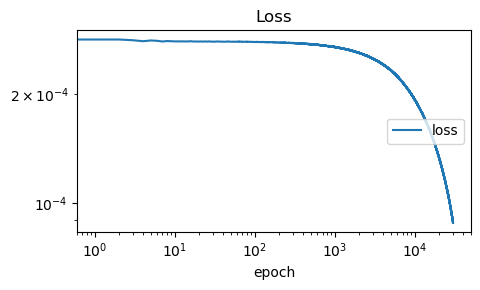

Epoch 30000/30000 Loss: 8.010e-05, Last_save: 29998: 100%|██████████| 30000/30000 [02:01<00:00, 247.47it/s]


In [ ]:
# Change the learning rate
lr = 1e-6

TIMESTEP = 20
filename = f'bestmodel_finetuned1_{TIMESTEP}.pt'
checkpoint = torch.load(savedir/filename, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
loss_fn = quantum_mean_infidelity
# loss_fn = mse
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# optimizer = pytorch_optimizer.SOAP(model.parameters(), lr=lr)
# lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=lr*0.001)
n_epochs = 30000
pbar = tqdm(range(n_epochs))
batch_size = 100
liveloss = PlotLosses(figsize=(9,3), outputs=outputs)

# Select a timestep
TIMESTEP = 20 # 20 --> 19
X, y = states_diffused[TIMESTEP], states_diffused[TIMESTEP-1]
ts = torch.ones_like(X) * TIMESTEP
train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y, ts), batch_size=batch_size, shuffle=True)

logs = {}
best_loss = float('inf')
last_save_epoch = 0
model.train()
for epoch in pbar:
    train_loss_epoch = 0
    for batch in train_dataloader:
        X, y, ts = batch
        # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        x = model(X)
        loss = loss_fn(x, y)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        train_loss_epoch += loss_value
    # lr_scheduler.step()
    avg_train_loss_epoch = train_loss_epoch / len(train_dataloader)
    logs['loss'] = avg_train_loss_epoch
    liveloss.update(logs)
    pbar.set_description(f'Epoch {epoch+1}/{n_epochs} Loss: {loss_value:.3e}, Last_save: {last_save_epoch}')

    if avg_train_loss_epoch < best_loss:
        best_loss = avg_train_loss_epoch
        last_save_epoch = epoch
        filename = f'bestmodel_finetuned2_{TIMESTEP}.pt'
        path = savedir/filename
        savedir.mkdir(parents=True, exist_ok=True)
        torch.save({
                'model_state_dict': model.state_dict(),
                'loss_hist': logs['loss'],
                }, path)
    if epoch % 299 == 0:
            liveloss.send()

Wass distance: 2.573e-02 --> 2.550e-02
Difference: 2.327e-04
Total Trainable Parameters: 2,404


/tmp/ipykernel_3347636/2757543331.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(savedir/filename)


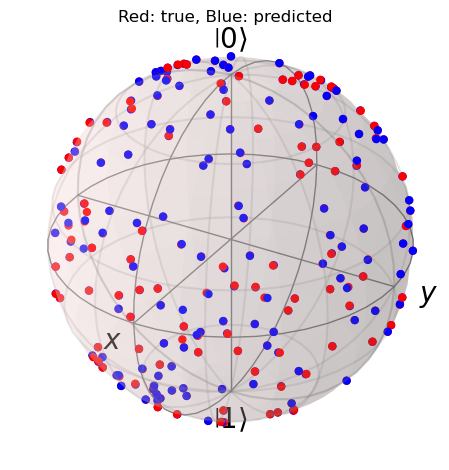

In [ ]:
# Print the evolution of the wass distance
X, y, ts = next(iter(train_dataloader))
x = eval(model, X)
wass_true = WassDistance(X, y)
wass_pred = WassDistance(X, x)
print(f'Wass distance: {wass_true:.3e} --> {wass_pred:.3e}')
print(f'Difference: {wass_true - wass_pred:.3e}')

# Print some stats of the model
n_params = sum(p.numel() for p in model.parameters())
print(f'Total Trainable Parameters: {n_params:,}')

# Bloch visualize on the forward noise process
filename = f'bestmodel_finetuned2_{TIMESTEP}.pt'
input_feats, n_hidden_layers, output_feats = 2**n_qubits, 3, 2**n_qubits
checkpoint = torch.load(savedir/filename)
model_finetuned = MLP(input_feats, n_hidden_layers, output_feats).to(device)
model_finetuned.load_state_dict(checkpoint['model_state_dict'])

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
b = Bloch(fig=fig, axes=ax)

y = states_diffused[TIMESTEP-1].numpy()
red_points = bloch_xyz(y) # True

X = states_diffused[TIMESTEP]
x = eval(model_finetuned, X)
x = x.detach().cpu().numpy()
blue_points = bloch_xyz(x)

all_points = [np.concatenate((red_points[i], blue_points[i])) for i in range(3)]
b.add_points(all_points)
b.point_color = ['r']*red_points[0].shape[0] + ['b']*blue_points[0].shape[0]
b.point_style = 'm'

b.render()
ax.set_title(f'Red: true, Blue: predicted')
plt.tight_layout()

# DEPRECATED

In [ ]:
import torch

def precision_test():
    # Set to float64 for high precision
    dtype = torch.float64
    device = "cpu"
    
    # 1. Check Machine Epsilon for float64
    eps = torch.finfo(dtype).eps
    print(f"Machine Epsilon for float64: {eps:.2e}")

    # 2. Create a 'true' unit vector
    n_features = 100
    true_state = torch.randn(n_features, dtype=dtype, device=device).to(torch.complex128)
    true_state = true_state / torch.linalg.norm(true_state)

    # 3. Create a 'pred' state that is slightly 'off' by a known delta
    # We move an amount 'delta' away from the true state
    delta_values = [1e-7, 1e-8, 1e-9, 1e-12, 1e-15]
    
    print(f"{'Target Delta':<15} | {'Computed Loss':<20} | {'Status'}")
    print("-" * 55)

    for delta in delta_values:
        # Perturb the state: pred = true + noise
        noise = torch.randn_like(true_state) * delta
        pred_state = true_state + noise
        
        # Re-normalize as your MLP does
        pred_state = pred_state / torch.linalg.norm(pred_state)
        
        # Calculate Fidelity and Loss
        inner_prod = torch.linalg.vecdot(true_state, pred_state)
        fidelity = inner_prod.abs().pow(2)
        loss = 1.0 - fidelity
        
        status = "OK" if loss > 0 else "ZERO/UNDERFLOW"
        print(f"{delta:<15} | {loss.item():<20.18e} | {status}")

precision_test()

Machine Epsilon for float64: 2.22e-16
Target Delta    | Computed Loss        | Status
-------------------------------------------------------
1e-07           | 1.100231017403530132e-12 | OK
1e-08           | 9.769962616701377556e-15 | OK
1e-09           | 0.000000000000000000e+00 | ZERO/UNDERFLOW
1e-12           | -8.881784197001252323e-16 | ZERO/UNDERFLOW
1e-15           | -8.881784197001252323e-16 | ZERO/UNDERFLOW
